In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
#1-6-26: this version removes class B2 and C GPCRs that do not have traditional binding pockets in the TM region. It also removes any system that has over 34% failed alignments.
df = pd.read_csv("pocket_similarity_and_identity_actual_gpcr_class_markedup_for_figure_1_6_26.csv")

# Column indices:
# 0 = human gene
# 6 = % identity
# 7 = % similarity



In [20]:
df

,human gene,zebrafish gene,actual class,matched,similarity,mismatched,failed alignments,% failed alignments,% identity,% similarity
0,GPR27,gpr27,Class_A,8,11,3,7,33.333333,72.73,100.00
1,GPR37L1,gpr37l1a,Class_A,9,9,3,6,33.333333,75.00,75.00
2,GPR37L1,gpr37l1b,Class_A,11,11,1,6,33.333333,91.67,91.67
3,GPR132,gpr132b,Class_A,11,12,1,6,31.578947,91.67,100.00
4,SSTR2,sstr2a,Class_A,12,14,2,7,30.434783,85.71,100.00
...,...,...,...,...,...,...,...,...,...,...
284,RXFP3,rxfp3,Class_A,15,16,1,0,0.000000,93.75,100.00
285,S1PR1,s1pr1,Class_A,17,17,0,0,0.000000,100.00,100.00
286,S1PR3,s1pr3a,Class_A,16,16,1,0,0.000000,94.12,94.12
287,TRHR,trhra,Class_A,18,19,1,0,0.000000,94.74,100.00


<Figure size 1200x600 with 0 Axes>

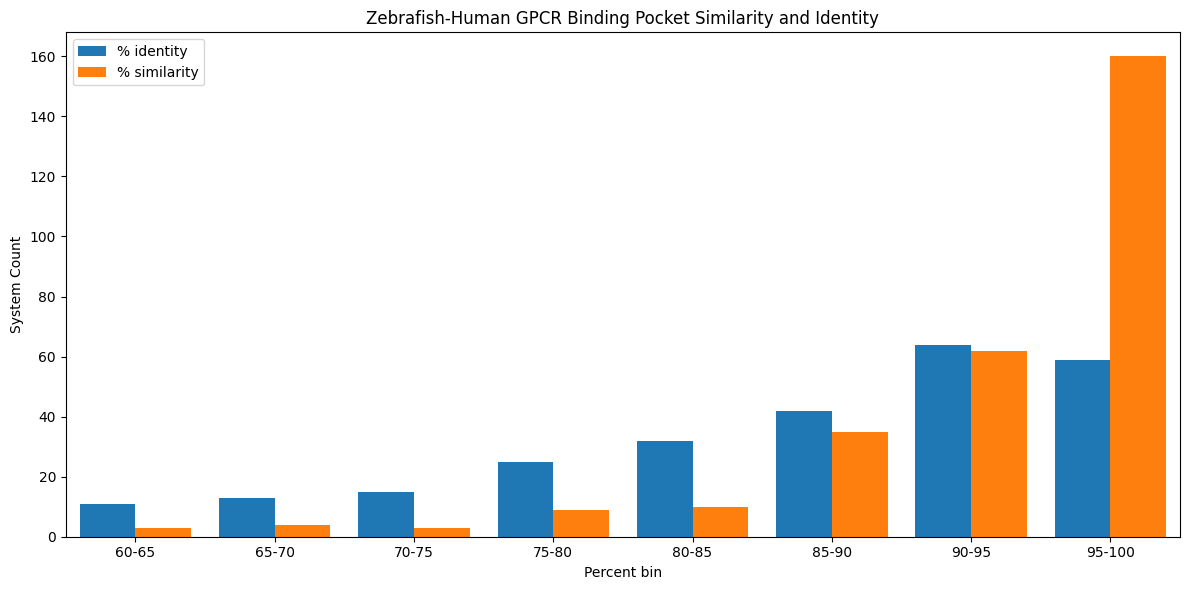

In [25]:
# Step 1 — keep only highest %identity row per unique zebrafish gene (switch from column 1 to 0 if wanting to do human)
df_best = df.loc[df.groupby(df.columns[1])[df.columns[8]].idxmax()]

identity = df_best.iloc[:, 8].values
similarity = df_best.iloc[:, 9].values

# Step 2 — define 5% bins
bins = np.arange(0, 105, 5)

# Step 3 — compute histogram counts manually
id_counts, _ = np.histogram(identity, bins=bins)
sim_counts, _ = np.histogram(similarity, bins=bins)

# bin centers for plotting
bin_centers = (bins[:-1] + bins[1:]) / 2

# bar width (smaller so both fit side by side)
width = 2.0

plt.figure(figsize=(12, 6))


""""
# Side-by-side bars
plt.bar(bin_centers - width, id_counts, width=width, label="% identity")
plt.bar(bin_centers + width, sim_counts, width=width, label="% similarity")

plt.xlabel("Percent Identity or Similarity Bins")
plt.ylabel("Systems Count")
#plt.title("Side-by-Side Histogram of Best % Identity and % Similarity")
plt.xticks(bins)
plt.legend()
plt.tight_layout()
plt.show()
"""
# define bin edges and centers
bins = np.arange(0, 105, 5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# select only bins 60–100
mask = bins[:-1] >= 60
bin_centers_plot = bin_centers[mask]
id_counts_plot = id_counts[mask]
sim_counts_plot = sim_counts[mask]

# create bin labels like "60–65", "65–70", ...
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
bin_labels_plot = [bin_labels[i] for i in range(len(bin_labels)) if mask[i]]


# bar width and small offset
width = 2.0

plt.figure(figsize=(12, 6))

#plt.bar(bin_centers  - width/2, id_counts, width=width, label="% identity")
#plt.bar(bin_centers  + width/2, sim_counts, width=width, label="% similarity")

plt.bar(bin_centers  - width/2, id_counts, width=width, label="% identity")
plt.bar(bin_centers  + width/2, sim_counts, width=width, label="% similarity")

plt.xticks(bin_centers_plot, bin_labels_plot)

plt.xlabel("Percent bin")
plt.ylabel("System Count")
plt.title("Zebrafish-Human GPCR Binding Pocket Similarity and Identity")
#plt.xticks(bins)
plt.xlim(60, 100)  # ensure full visibility of last bars
plt.legend()
plt.tight_layout()

plt.savefig("1-6-26_updated_identity_and_similarity_figure_zebrafish.svg", format="svg")

plt.show()


In [26]:
df_best

,human gene,zebrafish gene,actual class,matched,similarity,mismatched,failed alignments,% failed alignments,% identity,% similarity
83,ACKR3,ackr3a,Class_A,10,12,2,2,12.500000,83.33,100.00
37,ACKR3,ackr3b,Class_A,9,11,2,3,18.750000,81.82,100.00
224,ACKR4,ackr4b,Class_A,10,11,3,0,0.000000,76.92,84.62
225,ADCYAP1R1,adcyap1r1a,Class_B1,24,24,0,0,0.000000,100.00,100.00
226,ADORA1,adora1b,Class_A,19,19,0,0,0.000000,100.00,100.00
...,...,...,...,...,...,...,...,...,...,...
41,VIPR1,vipr1a,Class_B1,17,20,3,5,17.857143,85.00,100.00
151,VIPR2,vipr2,Class_B1,23,24,1,2,7.407407,95.83,100.00
210,XCR1,xcr1a.1,Class_A,11,13,8,1,4.545455,57.89,68.42
139,XCR1,xcr1b.1,Class_A,9,12,9,2,8.695652,50.00,66.67


In [27]:
df_best = (
    df.groupby(df.columns[1])
      .apply(lambda g: g.sort_values([g.columns[8], g.columns[9]], ascending=False).iloc[0])
      .reset_index(drop=True)
)

identity = df_best.iloc[:, 8].values
similarity = df_best.iloc[:, 9].values

# 5% bins
bins = np.arange(0, 105, 5)

# Histogram counts
id_counts, _ = np.histogram(identity, bins=bins)
sim_counts, _ = np.histogram(similarity, bins=bins)

#hold the total
id_total = 0
sim_total = 0

# Print formatted output
print("Bin Range   | Identity Count | Similarity Count")
print("----------------------------------------------")
for i in range(len(bins)-1):
    left = bins[i]
    right = bins[i+1]
    
    id_total = id_total + id_counts[i]
    sim_total = sim_total + sim_counts[i]
    
    print(f"{left:02d}–{right:02d}      | {id_counts[i]:>14} | {sim_counts[i]:>16}")
    
print(id_total, sim_total)

Bin Range   | Identity Count | Similarity Count
----------------------------------------------
00–05      |              0 |                0
05–10      |              0 |                0
10–15      |              1 |                0
15–20      |              0 |                0
20–25      |              1 |                0
25–30      |              0 |                0
30–35      |              2 |                0
35–40      |              1 |                0
40–45      |              1 |                1
45–50      |              6 |                0
50–55      |              7 |                1
55–60      |              9 |                1
60–65      |             11 |                3
65–70      |             13 |                4
70–75      |             15 |                3
75–80      |             25 |                9
80–85      |             32 |               10
85–90      |             42 |               35
90–95      |             64 |               62
95–100      

/tmp/ipykernel_1810624/1711884861.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values([g.columns[8], g.columns[9]], ascending=False).iloc[0])


<Figure size 1200x600 with 0 Axes>

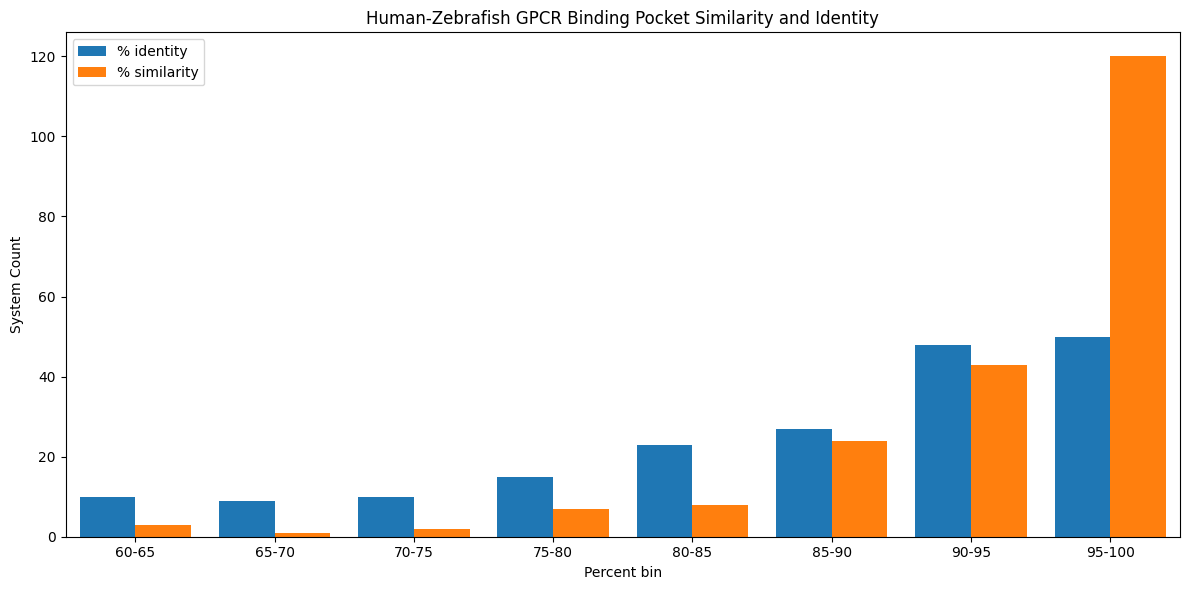

In [28]:
# Step 1 — keep only highest %identity row per unique zebrafish gene (switch from column 1 to 0 if wanting to do human)
df_best = df.loc[df.groupby(df.columns[0])[df.columns[8]].idxmax()]

identity = df_best.iloc[:, 8].values
similarity = df_best.iloc[:, 9].values

# Step 2 — define 5% bins
bins = np.arange(0, 105, 5)

# Step 3 — compute histogram counts manually
id_counts, _ = np.histogram(identity, bins=bins)
sim_counts, _ = np.histogram(similarity, bins=bins)

# bin centers for plotting
bin_centers = (bins[:-1] + bins[1:]) / 2

# bar width (smaller so both fit side by side)
width = 2.0

plt.figure(figsize=(12, 6))


""""
# Side-by-side bars
plt.bar(bin_centers - width, id_counts, width=width, label="% identity")
plt.bar(bin_centers + width, sim_counts, width=width, label="% similarity")

plt.xlabel("Percent Identity or Similarity Bins")
plt.ylabel("Systems Count")
#plt.title("Side-by-Side Histogram of Best % Identity and % Similarity")
plt.xticks(bins)
plt.legend()
plt.tight_layout()
plt.show()
"""
# define bin edges and centers
bins = np.arange(0, 105, 5)
bin_centers = (bins[:-1] + bins[1:]) / 2

# select only bins 60–100
mask = bins[:-1] >= 60
bin_centers_plot = bin_centers[mask]
id_counts_plot = id_counts[mask]
sim_counts_plot = sim_counts[mask]

# create bin labels like "60–65", "65–70", ...
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
bin_labels_plot = [bin_labels[i] for i in range(len(bin_labels)) if mask[i]]


# bar width and small offset
width = 2.0

plt.figure(figsize=(12, 6))

#plt.bar(bin_centers  - width/2, id_counts, width=width, label="% identity")
#plt.bar(bin_centers  + width/2, sim_counts, width=width, label="% similarity")

plt.bar(bin_centers  - width/2, id_counts, width=width, label="% identity")
plt.bar(bin_centers  + width/2, sim_counts, width=width, label="% similarity")

plt.xticks(bin_centers_plot, bin_labels_plot)

plt.xlabel("Percent bin")
plt.ylabel("System Count")
plt.title("Human-Zebrafish GPCR Binding Pocket Similarity and Identity")
#plt.xticks(bins)
plt.xlim(60, 100)  # ensure full visibility of last bars
plt.legend()
plt.tight_layout()

plt.savefig("1-6-26_updated_identity_and_similarity_figure_human.svg", format="svg")

plt.show()


In [ ]:
df_best = (
    df.groupby(df.columns[0])
      .apply(lambda g: g.sort_values([g.columns[8], g.columns[9]], ascending=False).iloc[0])
      .reset_index(drop=True)
)

identity = df_best.iloc[:, 8].values
similarity = df_best.iloc[:, 9].values

# 5% bins
bins = np.arange(0, 105, 5)

# Histogram counts
id_counts, _ = np.histogram(identity, bins=bins)
sim_counts, _ = np.histogram(similarity, bins=bins)

#hold the total
id_total = 0
sim_total = 0

# Print formatted output
print("Bin Range   | Identity Count | Similarity Count")
print("----------------------------------------------")
for i in range(len(bins)-1):
    left = bins[i]
    right = bins[i+1]
    
    id_total = id_total + id_counts[i]
    sim_total = sim_total + sim_counts[i]
    
    print(f"{left:02d}–{right:02d}      | {id_counts[i]:>14} | {sim_counts[i]:>16}")
    
print(id_total, sim_total)